In [ ]:
#r "nuget: ScottPlot, 5.0.*"


Installed Packages ScottPlot, 5.0.56

Loading extensions from `/home/artem/.nuget/packages/skiasharp/2.88.9/interactive-extensions/dotnet/SkiaSharp.DotNet.Interactive.dll`

Installed Packages skiasharp.nativeassets.linux.nodependencies, 2.88.9


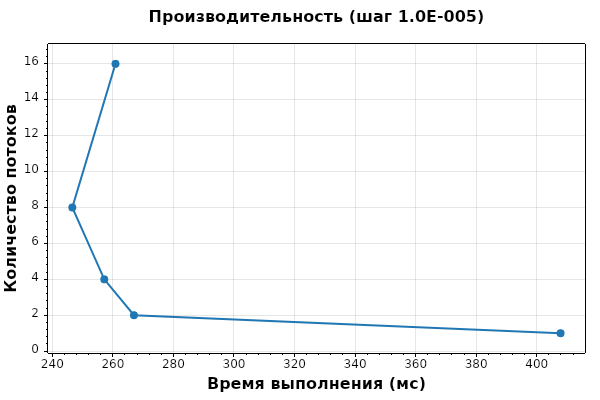

In [ ]:
#r "/home/artem/учёбаб/practice_2026/task14/bin/Debug/net8.0/task14.dll"

#r "nuget: SkiaSharp.NativeAssets.Linux.NoDependencies"

using System;
using System.Diagnostics;
using System.IO;
using System.Linq;
using System.Threading;
using ScottPlot;
using task14;
using Microsoft.DotNet.Interactive.Formatting;

Formatter.Register(typeof(ScottPlot.Plot), (p, w) =>
    w.Write(((ScottPlot.Plot)p).GetPngHtml(600, 400)), HtmlFormatter.MimeType);

ScottPlot.Fonts.Default = "DejaVu Sans";

double a = -100.0, b = 100.0;
var function = Math.Sin;
int iterations = 10;
Stopwatch sw = new Stopwatch();

double Median(double[] values)
{
    var sorted = values.OrderBy(v => v).ToArray();
    int mid = sorted.Length / 2;
    return sorted.Length % 2 == 0
        ? (sorted[mid - 1] + sorted[mid]) / 2.0
        : sorted[mid];
}


double[] steps = { 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6 };
const double exactValue = 0.0;
const double requiredPrecision = 1e-4;

foreach (var step in steps)
{
    double result = DefiniteIntegral.SolveSingleThread(a, b, function, step);
    double error = Math.Abs(result - exactValue);
    
}


double maxSingleThreadTimeMs = 500.0;
double optimalStep = steps[0];

foreach (var step in steps.AsEnumerable().Reverse())
{
    sw.Restart();
    DefiniteIntegral.SolveSingleThread(a, b, function, step);
    sw.Stop();
    double t = sw.Elapsed.TotalMilliseconds;
    

    if (t <= maxSingleThreadTimeMs)
    {
        optimalStep = step;
        maxSingleThreadTimeMs = t;
        break;
    }
}

int[] threadCounts = { 1, 2, 4, 8, 16 };
double[] avgTimes = new double[threadCounts.Length];
int optimalThreads = 1;
double minMultiThreadTime = double.MaxValue;

for (int i = 0; i < threadCounts.Length; i++)
{
    double[] samples = new double[iterations];
    for (int j = 0; j < iterations; j++)
    {
        sw.Restart();
        DefiniteIntegral.SolveMultiThread(a, b, function, optimalStep, threadCounts[i]);
        sw.Stop();
        samples[j] = sw.Elapsed.TotalMilliseconds;
    }
    avgTimes[i] = Median(samples);

    if (avgTimes[i] < minMultiThreadTime)
    {
        minMultiThreadTime = avgTimes[i];
        optimalThreads = threadCounts[i];
    }
}

double[] singleThreadSamples = new double[iterations];
for (int i = 0; i < iterations; i++)
{
    sw.Restart();
    DefiniteIntegral.SolveSingleThread(a, b, function, optimalStep);
    sw.Stop();
    singleThreadSamples[i] = sw.Elapsed.TotalMilliseconds;
}
double singleThreadTime = Median(singleThreadSamples);

double finalSpeedupPercent = ((singleThreadTime - minMultiThreadTime) / singleThreadTime) * 100.0;

string filePath = "results.txt";
using (StreamWriter writer = new StreamWriter(filePath))
{
    writer.WriteLine($"Оптимальный размер шага: {optimalStep:E1}");
    writer.WriteLine($"Оптимальное количество потоков: {optimalThreads}");
    writer.WriteLine($"Скорость однопоточной версии: {singleThreadTime:F2} мс");
    writer.WriteLine($"Скорость многопоточной версии: {minMultiThreadTime:F2} мс");
    writer.WriteLine($"Ускорение: {finalSpeedupPercent:F2}%");
}

var plt = new ScottPlot.Plot();
var scatter = plt.Add.Scatter(avgTimes, threadCounts.Select(t => (double)t).ToArray());
scatter.MarkerSize = 8;
scatter.LineWidth = 2;
plt.XLabel("Время выполнения (мс)");
plt.YLabel("Количество потоков");
plt.Title($"Производительность (шаг {optimalStep:E1})");

plt.SavePng("plot.png", 800, 600);

plt
